# Routing

## Definition of Routing

Routing in LangGraph refers to the ability to **conditionally determine which node to execute next** based on the current state or the output of a node.

This is typically implemented using:
- **`add_conditional_edges`** — A method that maps a node's output or a condition function's result to different possible next nodes.
- **State** — The workflow's state can store variables that influence routing decisions.
- **Condition Functions** — Functions that evaluate the state or node output to decide the next step.

## How Routing Works with LangGraph

1. **Receive the Input:** The workflow receives an input that needs to be processed.

2. **Create a Router:** A router evaluates the current state or input and determines which path should be followed.

3. **Define Conditional Paths:** Multiple possible nodes are connected to the router using conditional edges.

4. **Execute the Selected Node:** Based on the routing decision, the graph executes the appropriate downstream node.

5. **Generate the Output:** The selected node processes the input and produces the output.


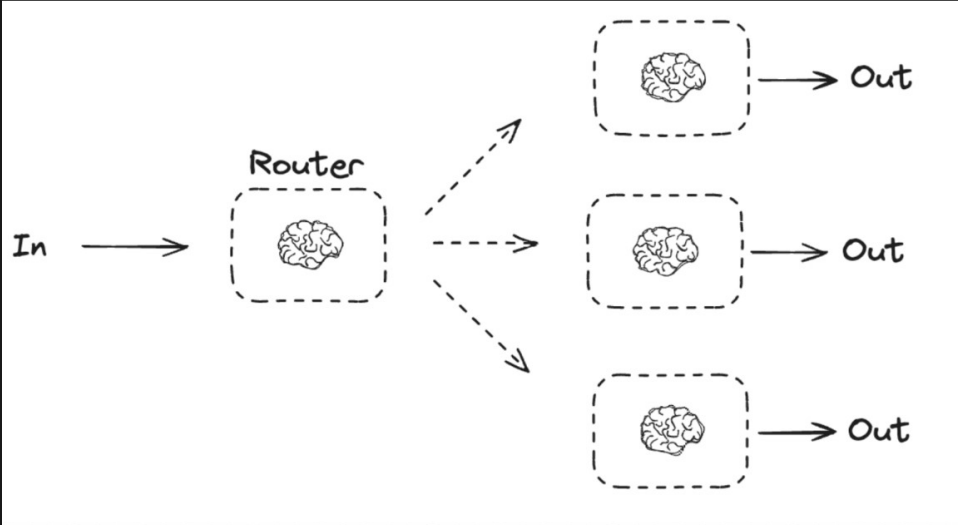

## Key Concepts

- **Dynamic Flow:** Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- **Condition Logic:** You define rules such as **"if this, go here; if that, go there."**

- **Conditional Edges:** `add_conditional_edges` connects a node to different possible next nodes based on a routing decision.

- **Flexibility:** Routing can be combined with **parallelization** or **sequential chains** to build complex workflows.

## Benefits of Routing with LangGraph

- **Dynamic Workflows:** Allows the graph to choose different execution paths based on the current state or result.

- **Better Decision Making:** Enables workflows to apply conditions and make appropriate routing decisions.

- **Flexible Architecture:** Supports multiple execution paths within the same graph.

- **Efficient Processing:** Only the required node or path needs to be executed for a given condition.

- **Handles Complex Workflows:** Makes it easier to build workflows involving conditional logic, branching, and different outcomes.

- **Easy to Combine:** Routing can be combined with **prompt chaining**, **parallelization**, and other LangGraph patterns.

## Problem Statement

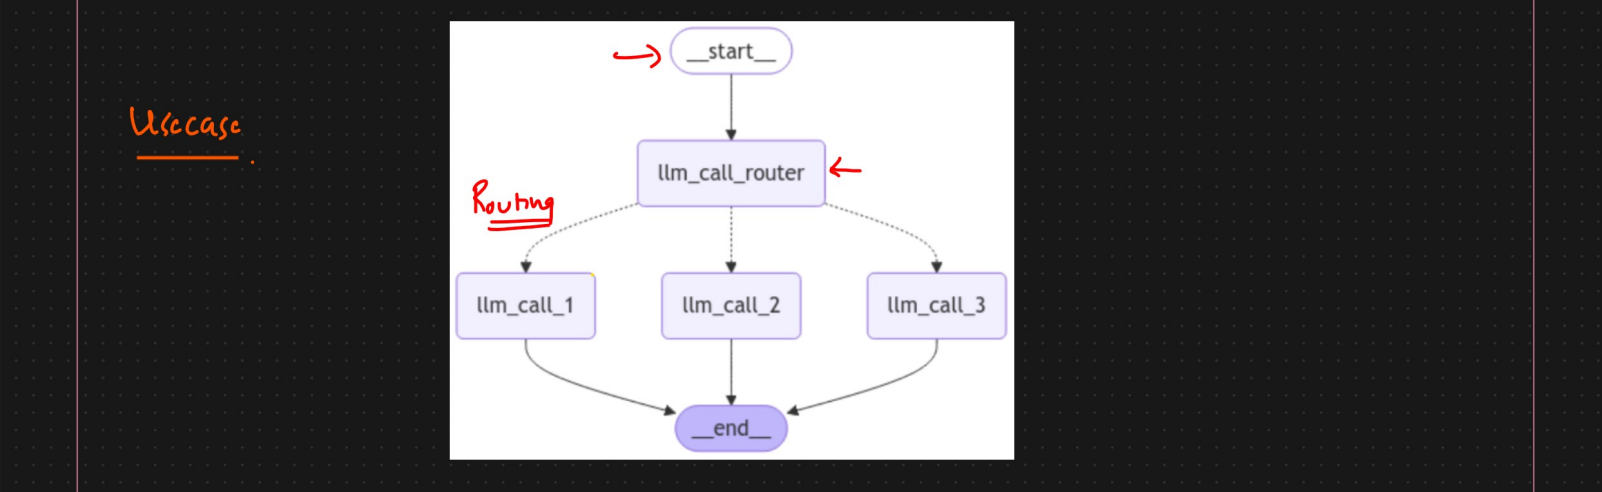

## Solution

### Setting Up the Chat Model

In [2]:
### Importing Required Libraries
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="openai/gpt-oss-120b")

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We have a conversation: system, developer, user says "Hello". We need to respond. The developer message says: "You are ChatGPT, ...". The user says "Hello". So we should respond politely. There\'s no policy violation. Just a greeting. We\'ll respond.'}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 72, 'total_tokens': 147, 'completion_time': 0.155851662, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.003916856, 'prompt_tokens_details': None, 'queue_time': 0.351199769, 'total_time': 0.159768518}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fb68-ddc5-7731-81ef-a9ae1010085d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 75, 'total_tokens': 147, 'out

### Defining the State Schema and Graph Nodes

In [4]:
from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(description="The next step in the routing process")

## Augment the LLM with schema for structured output
router=llm.with_structured_output(Route)

### Creating the Graph State
class State(TypedDict):
    input:str
    decision:str
    output:str

### Defining the Graph Nodes

In [5]:
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    print("LLM call 2 is called")

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to the appropriate node"""

    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    return {"decision":decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

### Building the Routing Graph

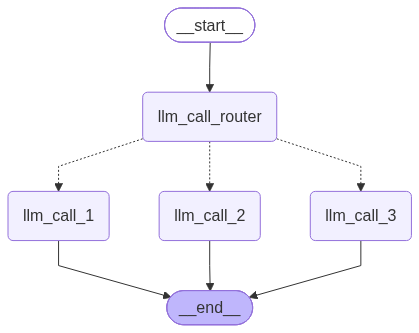

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

### Creating the StateGraph
router_builder = StateGraph(State)

### Adding the Graph Nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

### Adding the Graph Edges
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

### Compiling the Graph
router_workflow = router_builder.compile()

### Visualizing the Graph
display(Image(router_workflow.get_graph().draw_mermaid_png()))

### Running the Routing Graph

#### Routing a Story Request

In [10]:
state=router_workflow.invoke({"input":"Write me a story about Iron Man in short"})
print(state["output"])

**Iron Man: The Midnight Test**

The city lights of New York flickered like a circuit board as night settled over the skyline. In the heart of the bustling streets, a lone figure hovered above a rooftop—Tony Stark, encased in his gleaming red‑gold armor, the arc reactor pulsing softly against his chest.

A sudden alarm blared from his HUD: **“Unidentified aerial anomaly—high velocity, hostile signature.”** He glanced down at the streets below, where a sleek, black drone weaved between skyscrapers, its payload glowing ominously.

“Looks like someone’s trying to rewrite the rules,” Tony muttered, tapping a command into his suit’s interface. The repulsors ignited, sending a burst of blue‑white light that propelled him forward. He cut through the night air, the wind whipping against his helmet.

The drone darted toward a downtown power substation, its weapon charging. Tony’s suit automatically adjusted, deploying a magnetic field that deflected a volley of electromagnetic pulses. He landed

#### Routing a Joke Request

In [11]:
state=router_workflow.invoke({"input":"Write me a joke about Rohit Sharma"})
print(state["output"])

LLM call 2 is called
Sure, here’s a light‑hearted cricket‑themed one:

**Why does Rohit Sharma always carry a map on the field?**  
Because whenever he’s at the crease, he’s *always* finding new “boundaries”! 😄


#### Routing a Poem Request

In [20]:
state=router_workflow.invoke({"input":"Write me a poem on Avengers with 2 lines each"})
print(state["output"])

**Avengers’ Anthem**

In iron armor, Stark ignites the night,  
A heart of fire beneath the circuit’s light.  

Thor’s thunder rolls across the storm‑worn sky,  
His hammer sings where ancient legends lie.  

Captain America lifts his shield of hope,  
A steadfast star that helps the world to cope.  

Black Widow’s shadows dance in silent grace,  
A whispered strike that finds the hidden base.  

Hulk’s fury bursts, a mountain’s roaring roar,  
Yet gentle eyes reveal a soul once more.  

Vision’s crystal mind reflects the dawn,  
A perfect blend of flesh and code reborn.  

Together they stand, a world‑wide choir,  
Guardians of peace, forever higher.
